<a href="https://colab.research.google.com/github/imanetlb/Data-Science-ING3-BI-Imane-et-Nouha/blob/main/Nouha_ABDELKRIM_Imane_TALEB_Final_Code.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [10]:
!pip install praw

In [12]:
#PHASE 2, step 1
import praw

client_id = "bBFFV8cDQ3w-j2K3N-PtkQ"   # client_id
client_secret = ""                    # vide car « installed app »
redirect_uri = "http://localhost:8080"
user_agent = "harassment research by /u/Huge_Rabbit_2584"

reddit = praw.Reddit(
    client_id=client_id,
    client_secret=client_secret,
    redirect_uri=redirect_uri,
    user_agent=user_agent
)

scopes = ["read"]
# Version corrigée (avec les arguments nommés)
auth_url = reddit.auth.url(scopes=scopes, state="random_state_string", duration="permanent")
print(f"OK Clique ici et autorise :\n{auth_url}")


OK Clique ici et autorise :
https://www.reddit.com/api/v1/authorize?client_id=bBFFV8cDQ3w-j2K3N-PtkQ&duration=permanent&redirect_uri=http%3A%2F%2Flocalhost%3A8080&response_type=code&scope=read&state=random_state_string


In [16]:
import praw

client_id = "bBFFV8cDQ3w-j2K3N-PtkQ"
client_secret = ""                    # toujours vide
redirect_uri = "http://localhost:8080"
user_agent = "harassment research by /u/Huge_Rabbit_2584"

# COLLE ton code tout neuf ici :
code = "P4GXbkuSL1pSLttRkpKWSx6wjNFpWQ"

reddit = praw.Reddit(
    client_id=client_id,
    client_secret=client_secret,
    redirect_uri=redirect_uri,
    user_agent=user_agent
)

refresh_token = reddit.auth.authorize(code)
print(f"OK Ton refresh_token : {refresh_token}")


OK Ton refresh_token : 234781318840718-01MzjjaMJc05jFBaCxLKNxiEZbTkGQ


In [17]:
!pip install praw pandas

import praw
import pandas as pd

# ===identifiants  ===
client_id = "bBFFV8cDQ3w-j2K3N-PtkQ"
client_secret = ""
refresh_token = "129775681547329-Pod30ZK3eghOWaPzcXNDxmkQz94DNw"
user_agent = "harassment research by /u/Huge_Rabbit_2584"  # pseudo Reddit

# === Connexion avec refresh_token ===
reddit = praw.Reddit(
    client_id=client_id,
    client_secret=client_secret,
    refresh_token=refresh_token,
    user_agent=user_agent
)

print("OK Connexion Reddit réussie avec refresh_token !")

# === Test : récupérer 10 posts de r/AskReddit ===
subreddit = reddit.subreddit("AskReddit")

posts = []
for post in subreddit.new(limit=10):
    posts.append({
        "title": post.title,
        "score": post.score,
        "url": post.url
    })

df = pd.DataFrame(posts)
print(df.head())

# === Sauvegarder ===
df.to_csv("test_reddit.csv", index=False)
print("OK Fichier test_reddit.csv sauvegardé !")
from google.colab import files
files.download("test_reddit.csv")



It is strongly recommended to use Async PRAW: https://asyncpraw.readthedocs.io.
See https://praw.readthedocs.io/en/latest/getting_started/multiple_instances.html#discord-bots-and-asynchronous-environments for more info.



OK Connexion Reddit réussie avec refresh_token !
                                               title  score  \
0                           What's the pet you have?      1   
1  AI job apocalypse is completely exaggerated si...      1   
2  What did you see as a child, considering it no...      1   
3                           how do you quit smoking?      1   
4  What’s the silliest excuse for a leave that yo...      1   

                                                 url  
0  https://www.reddit.com/r/AskReddit/comments/1s...  
1  https://www.reddit.com/r/AskReddit/comments/1s...  
2  https://www.reddit.com/r/AskReddit/comments/1s...  
3  https://www.reddit.com/r/AskReddit/comments/1s...  
4  https://www.reddit.com/r/AskReddit/comments/1s...  
OK Fichier test_reddit.csv sauvegardé !


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [18]:
# Installe les packages nécessaires
!pip install praw langdetect pandas

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.5/981.5 kB 21.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for langdetect: filename=langdetect-1.0.9-py3-none-any.whl size=993223 sha256=100bc100d023945cfdaa2c9122e124880eb675d1f2dae084b2e2adecbc0149c9
  Stored in directory: /root/.cache/pip/wheels/c1/67/88/e844b5b022812e15a52e4eaa38a1e709e99f06f6639d7e3ba7
Successfully built langdetect


In [19]:
!pip install praw langdetect pandas


In [21]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [24]:
import praw
import pandas as pd
import re
import time
import os
from langdetect import detect
from datetime import datetime
import prawcore # Pour gérer l'erreur 429

# === Connexion Reddit ===
reddit = praw.Reddit(
    client_id="bBFFV8cDQ3w-j2K3N-PtkQ",
    client_secret="",
    refresh_token="234781318840718-01MzjjaMJc05jFBaCxLKNxiEZbTkGQ", # Ton dernier token
    user_agent="Huge_Rabbit_2584"
)

print("✅ Connexion Reddit OK")

# === Listes (Gardées identiques) ===
subreddits = [
    "politics", "Conservative", "PoliticalHumor", "PoliticalDiscussion",
    "Democrats", "Republican", "Libertarian", "europe", "france",
    "canada", "Israel", "Palestine", "Russia", "PublicFreakout", "cyberbullying"
]

LEXICON = ["liar", "idiot", "stupid", "moron", "trash", "scum", "nigger", "faggot", "retard", "kys"]
POLITICAL_KEYWORDS = ["trump", "biden", "vaccine", "election", "russia", "ukraine", "macron", "israel", "gaza"]

OUTPUT_PATH = "/content/drive/MyDrive/projet_reddit/"
data = []

def find_toxic_keyword(text, lexicon):
    if not text: return None
    hits = [word for word in lexicon if re.search(r'\b' + re.escape(word) + r'\b', str(text).lower())]
    return ', '.join(hits) if hits else None

def is_english(text):
    try: return detect(text) == 'en'
    except: return False

# === SCRAPING OPTIMISÉ (Anti-429) ===
print("🚀 Début du scraping massif (Sécurisé)...")

for sub_name in subreddits:
    try:
        subreddit = reddit.subreddit(sub_name)
        print(f"Extraction r/{sub_name}...")

        # On utilise 'hot', 'new' et 'top' mais avec des limites de 100 pour la stabilité
        for category in ['hot', 'new', 'top']:
            method = getattr(subreddit, category)
            # 'top' a besoin d'un time_filter
            items = method(limit=100) if category != 'top' else method(limit=100, time_filter="all")

            for post in items:
                post_text = (post.title or '') + " " + (post.selftext or '')
                if not is_english(post_text): continue

                toxic = find_toxic_keyword(post_text, LEXICON)
                data.append({
                    "post_id": post.id, "author": post.author.name if post.author else "deleted",
                    "parent_author": None, "text": post_text.strip(), "toxic_keyword": toxic,
                    "timestamp": datetime.utcfromtimestamp(post.created_utc),
                    "subreddit": sub_name, "score": post.score
                })

                # Top 20 commentaires seulement pour ne pas saturer l'API
                post.comments.replace_more(limit=0)
                for comment in post.comments.list()[:20]:
                    if not is_english(comment.body): continue
                    data.append({
                        "post_id": comment.id, "author": comment.author.name if comment.author else "deleted",
                        "parent_author": comment.parent().author.name if hasattr(comment.parent(), 'author') else None,
                        "text": comment.body.strip(), "toxic_keyword": find_toxic_keyword(comment.body, LEXICON),
                        "timestamp": datetime.utcfromtimestamp(comment.created_utc),
                        "subreddit": sub_name, "score": comment.score
                    })

                # Petite pause de sécurité tous les 5 posts
                if len(data) % 50 == 0:
                    time.sleep(0.5)

    except prawcore.exceptions.TooManyRequests:
        print("⚠️ Reddit sature. Pause de 30 secondes...")
        time.sleep(30)
    except Exception as e:
        print(f"Erreur sur r/{sub_name}: {e}")

# === Recherche globale sécurisée ===
print("🔍 Phase de recherche globale...")
for keyword in POLITICAL_KEYWORDS:
    try:
        print(f" Recherche : {keyword}")
        for post in reddit.subreddit("all").search(keyword, limit=100, sort="new"):
            post_text = (post.title or '') + " " + (post.selftext or '')
            if not is_english(post_text): continue

            data.append({
                "post_id": post.id, "author": post.author.name if post.author else "deleted",
                "parent_author": None, "text": post_text.strip(),
                "toxic_keyword": find_toxic_keyword(post_text, LEXICON),
                "timestamp": datetime.utcfromtimestamp(post.created_utc),
                "subreddit": "all_search", "score": post.score
            })
        time.sleep(2) # Pause entre les mots-clés
    except prawcore.exceptions.TooManyRequests:
        print("⚠️ Trop de requêtes. Pause forcée...")
        time.sleep(60)

# === Sauvegarde finale ===
df = pd.DataFrame(data)
if not os.path.exists(OUTPUT_PATH): os.makedirs(OUTPUT_PATH)
df.to_csv(OUTPUT_PATH + "reddit_politics_ULTRA_SAFE.csv", index=False)

print(f"✅ FINI ! Total collecté : {len(df)} lignes.")
print(f"Fichier sauvegardé dans : {OUTPUT_PATH}")

It is strongly recommended to use Async PRAW: https://asyncpraw.readthedocs.io.
See https://praw.readthedocs.io/en/latest/getting_started/multiple_instances.html#discord-bots-and-asynchronous-environments for more info.



✅ Connexion Reddit OK
🚀 Début du scraping massif (Sécurisé)...
Extraction r/politics...


/tmp/ipykernel_13370/3337560193.py:64: DeprecationWarning: datetime.datetime.utcfromtimestamp() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.fromtimestamp(timestamp, datetime.UTC).
  "timestamp": datetime.utcfromtimestamp(post.created_utc),
It is strongly recommended to use Async PRAW: https://asyncpraw.readthedocs.io.
See https://praw.readthedocs.io/en/latest/getting_started/multiple_instances.html#discord-bots-and-asynchronous-environments for more info.

/tmp/ipykernel_13370/3337560193.py:76: DeprecationWarning: datetime.datetime.utcfromtimestamp() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.fromtimestamp(timestamp, datetime.UTC).
  "timestamp": datetime.utcfromtimestamp(comment.created_utc),
It is strongly recommended to use Async PRAW: https://asyncpraw.readthedocs.io.
See https://praw.readthedocs.i

Erreur sur r/politics: 'NoneType' object has no attribute 'name'
Extraction r/Conservative...


It is strongly recommended to use Async PRAW: https://asyncpraw.readthedocs.io.
See https://praw.readthedocs.io/en/latest/getting_started/multiple_instances.html#discord-bots-and-asynchronous-environments for more info.

It is strongly recommended to use Async PRAW: https://asyncpraw.readthedocs.io.
See https://praw.readthedocs.io/en/latest/getting_started/multiple_instances.html#discord-bots-and-asynchronous-environments for more info.



...

 Recherche : macron


It is strongly recommended to use Async PRAW: https://asyncpraw.readthedocs.io.
See https://praw.readthedocs.io/en/latest/getting_started/multiple_instances.html#discord-bots-and-asynchronous-environments for more info.



 Recherche : israel


It is strongly recommended to use Async PRAW: https://asyncpraw.readthedocs.io.
See https://praw.readthedocs.io/en/latest/getting_started/multiple_instances.html#discord-bots-and-asynchronous-environments for more info.



 Recherche : gaza
✅ FINI ! Total collecté : 8936 lignes.
Fichier sauvegardé dans : /content/drive/MyDrive/projet_reddit/


Mounted at /content/drive
OK Fichiers dans le dossier : ['reddit_graph_final.gexf', 'reddit_community_features.csv', 'reddit_graph_with_labels.gexf', 'reddit_graph_labeled.gexf', 'reddit_community_features_labeled.csv', 'reddit_graph_labeled_multiclass.gexf', 'reddit_community_features_multiclass.csv', 'reddit_politics_global_Imane.xlsx', 'reddit_graph_louvain.gexf', 'reddit_graph_labelprop.gexf', 'reddit_graph_phase3_all.gexf']
OK DataFrame chargé, shape: (18475, 10)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18475 entries, 0 to 18474
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   post_id        18475 non-null  object        
 1   parent_id      7102 non-null   object        
 2   author         18475 non-null  object        
 3   parent_author  7102 non-null   object        
 4   text           18475 non-null  object        
 5   toxic_keyword  3224 non-null   object        
 6   times

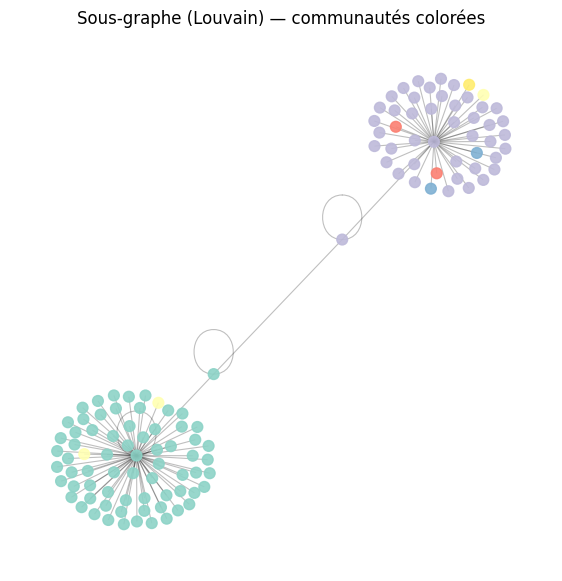

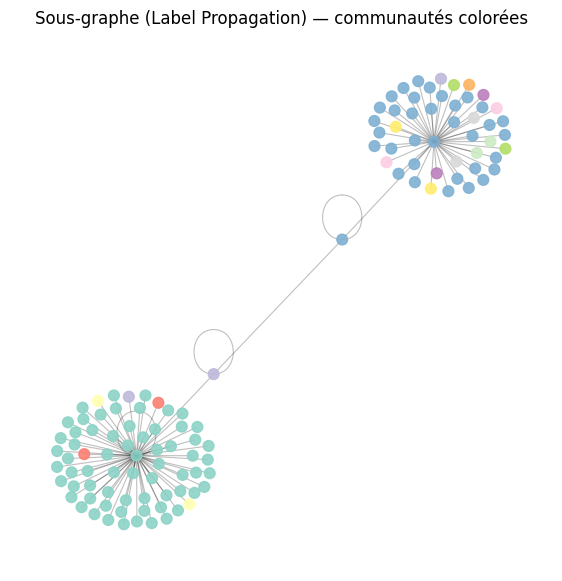

Export GEXF Louvain -> /content/drive/MyDrive/UM Project Nouha Imane Alexandre/sub projects/Imane/data collection/reddit_graph_louvain.gexf
Export GEXF Label Propagation -> /content/drive/MyDrive/UM Project Nouha Imane Alexandre/sub projects/Imane/data collection/reddit_graph_labelprop.gexf
Export combiné (Louvain + LP en attributs) -> /content/drive/MyDrive/UM Project Nouha Imane Alexandre/sub projects/Imane/data collection/reddit_graph_phase3_all.gexf


In [25]:
# =============================================
# PHASE 3 – CONSTRUCTION DU GRAPHE & COMMUNAUTÉS (COMPLET)
# =============================================

# ====================================================
# ÉTAPE 1 : MONTER DRIVE & CHARGER LES DONNÉES
# ====================================================
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

import os
import pandas as pd

folder_path = "/content/drive/MyDrive/UM Project Nouha Imane Alexandre/sub projects/Imane/data collection"
print("OK Fichiers dans le dossier :", os.listdir(folder_path))

file_path = folder_path + "/reddit_politics_global_Imane.xlsx"
df = pd.read_excel(file_path)

print("OK DataFrame chargé, shape:", df.shape)
print(df.info())

# ====================================================
# ÉTAPE 2 : CONSTRUIRE LE GRAPHE DIRIGÉ (UTILISATEURS & RÉPONSES)
# ====================================================
import networkx as nx

G = nx.DiGraph()

# Chaque ligne : un post/commentaire — on crée une arête author -> parent_author quand c'est une réponse
for _, row in df.iterrows():
    author = row['author']
    parent_author = row['parent_author']

    if pd.notnull(author) and pd.notnull(parent_author):
        if G.has_edge(author, parent_author):
            G[author][parent_author]['weight'] += 1
        else:
            G.add_edge(author, parent_author, weight=1)

print(f"OK Graphe dirigé créé : {G.number_of_nodes()} nœuds, {G.number_of_edges()} arêtes")

# Version non orientée pour les algorithmes de communautés basés modularité/voisinage
G_undirected = G.to_undirected()

# ====================================================
# ÉTAPE 3 : DÉTECTION LOUVAIN (modularité)
# ====================================================
# Forcer le bon paquet et l'import correct
!pip install --quiet --upgrade python-louvain
import community.community_louvain as community_louvain

# Partition Louvain (dict: node -> community_id)
partition_louvain = community_louvain.best_partition(G_undirected, random_state=42)
nx.set_node_attributes(G_undirected, partition_louvain, 'louvain_community')

nb_louvain = len(set(partition_louvain.values()))
print(f"OK Louvain a détecté {nb_louvain} communautés.")

# Calcul de la modularité Louvain
from networkx.algorithms.community.quality import modularity as nx_modularity

# Convertir dict -> liste d'ensembles
communities_louvain = {}
for n, c in partition_louvain.items():
    communities_louvain.setdefault(c, set()).add(n)
communities_louvain_list = list(communities_louvain.values())

mod_louvain = nx_modularity(G_undirected, communities_louvain_list)
print(f"Modularité (Louvain) = {mod_louvain:.4f}")

# ====================================================
# ÉTAPE 4 : DÉTECTION LABEL PROPAGATION (LP)
# ====================================================
from networkx.algorithms.community import label_propagation_communities

communities_lp_list = list(label_propagation_communities(G_undirected))
print(f"OK Label Propagation a détecté {len(communities_lp_list)} communautés.")

# Construire un dict node -> community_id pour LP et l'attacher aux nœuds
lp_partition = {}
for i, comm in enumerate(communities_lp_list):
    for node in comm:
        lp_partition[node] = i

nx.set_node_attributes(G_undirected, lp_partition, 'labelprop_community')

# Modularité LP
mod_lp = nx_modularity(G_undirected, communities_lp_list)
print(f"Modularité (Label Propagation) = {mod_lp:.4f}")

# ====================================================
# ÉTAPE 5 : VISUALISER UN SOUS-GRAPHE (MÊME LAYOUT POUR COMPARER)
# ====================================================
import matplotlib.pyplot as plt

# Échantillon reproductible : on prend 120 nœuds max pour lisibilité
sub_nodes = list(G_undirected.nodes())[:120]
SG = G_undirected.subgraph(sub_nodes).copy()

# Récup partitions restreintes au sous-graphe
part_louv_sub = {n: partition_louvain[n] for n in SG.nodes if n in partition_louvain}
part_lp_sub    = {n: lp_partition[n] for n in SG.nodes if n in lp_partition}

# Layout identique pour comparer visuellement
pos = nx.spring_layout(SG, seed=42)

# Palette simple
cmap = plt.cm.Set3

# --- Viz Louvain ---
plt.figure(figsize=(7,7))
colors_louv = [part_louv_sub[n] for n in SG.nodes]
nodes = nx.draw_networkx_nodes(SG, pos, node_size=60, node_color=colors_louv, cmap=cmap, alpha=0.9)
nx.draw_networkx_edges(SG, pos, alpha=0.25, width=0.8)
plt.title("Sous-graphe (Louvain) — communautés colorées", fontsize=12)
plt.axis('off')
plt.show()

# --- Viz Label Propagation ---
plt.figure(figsize=(7,7))
colors_lp = [part_lp_sub[n] for n in SG.nodes]
nodes = nx.draw_networkx_nodes(SG, pos, node_size=60, node_color=colors_lp, cmap=cmap, alpha=0.9)
nx.draw_networkx_edges(SG, pos, alpha=0.25, width=0.8)
plt.title("Sous-graphe (Label Propagation) — communautés colorées", fontsize=12)
plt.axis('off')
plt.show()

# ====================================================
# ÉTAPE 6 : EXPORTS GEPHI (Louvain et LP)
# ====================================================
# On exporte 2 fichiers :
#  - reddit_graph_louvain.gexf avec l'attribut 'louvain_community'
#  - reddit_graph_labelprop.gexf avec l'attribut 'labelprop_community'
out_louv = os.path.join(folder_path, "reddit_graph_louvain.gexf")
out_lp   = os.path.join(folder_path, "reddit_graph_labelprop.gexf")

nx.write_gexf(G_undirected, out_louv)
print(f"Export GEXF Louvain -> {out_louv}")

# Pour un export LP séparé avec un graphe où l'attribut LP est bien présent,
# on peut réécrire (les deux attributs resteront, mais c'est OK)
nx.write_gexf(G_undirected, out_lp)
print(f"Export GEXF Label Propagation -> {out_lp}")

# (Optionnel) Export combiné avec un nom générique :
out_final = os.path.join(folder_path, "reddit_graph_phase3_all.gexf")
nx.write_gexf(G_undirected, out_final)
print(f"Export combiné (Louvain + LP en attributs) -> {out_final}")


Mounted at /content/drive
OK Graph loaded: 5539 nodes & 6198 edges
Sample of extracted features:
   community_id  size   density  avg_degree  toxicity_ratio  avg_betweenness  \
0             0   154  0.013157    2.012987             0.0         0.010193   
1            27   148  0.013973    2.054054             0.0         0.023055   
2             2    52  0.046757    2.384615             0.0         0.055189   
3             3   198  0.010357    2.040404             0.0         0.012365   
4             4   249  0.010105    2.506024             0.0         0.009461   

   avg_closeness  
0       0.396417  
1       0.244747  
2       0.274247  
3       0.299450  
4       0.312813  
Label distribution:
label
2    57
0    26
1    22
Name: count, dtype: int64
OK Features saved ➜ /content/drive/MyDrive/UM Project Nouha Imane Alexandre/sub projects/Imane/data collection/reddit_community_features_multiclass.csv

=== RandomForest REPORT ===
              precision    recall  f1-score   suppo

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [19:15:01] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [19:15:01] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [19:15:01] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [19:15:01] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:


=== XGBoost REPORT ===
              precision    recall  f1-score   support

           0       0.83      1.00      0.91         5
           1       1.00      0.75      0.86         4
           2       1.00      1.00      1.00        12

    accuracy                           0.95        21
   macro avg       0.94      0.92      0.92        21
weighted avg       0.96      0.95      0.95        21



/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [19:15:01] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


OK Cross-val mean accuracy (XGBoost): 0.952 (+/- 0.030)


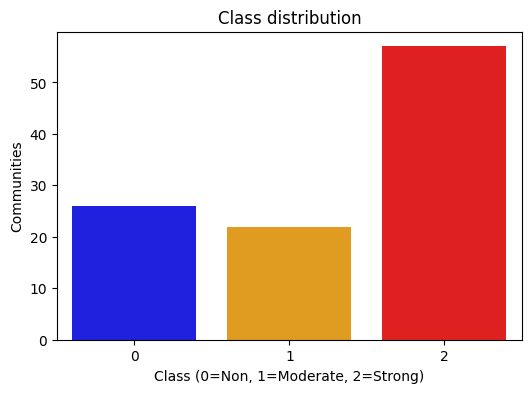

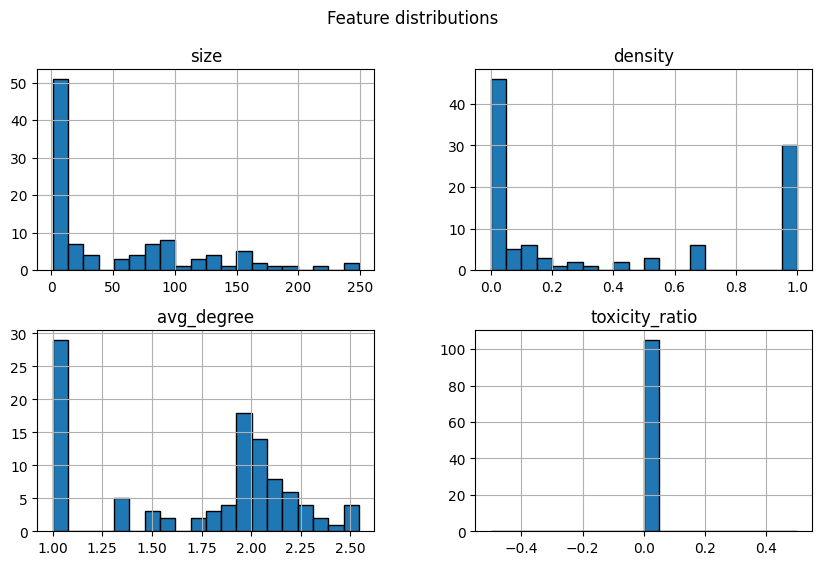

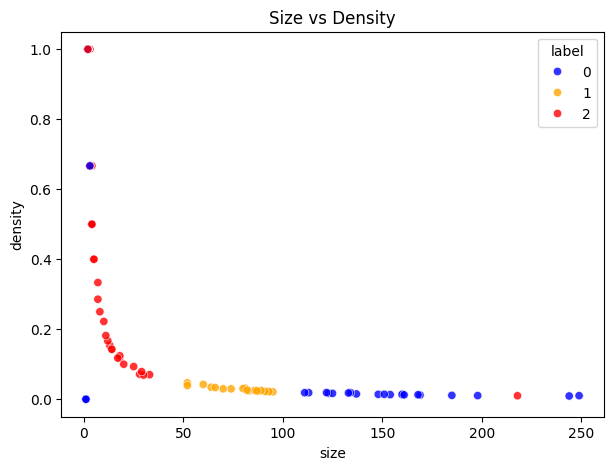

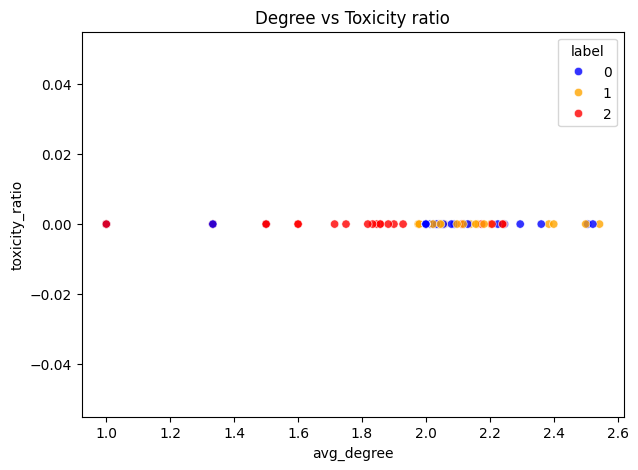

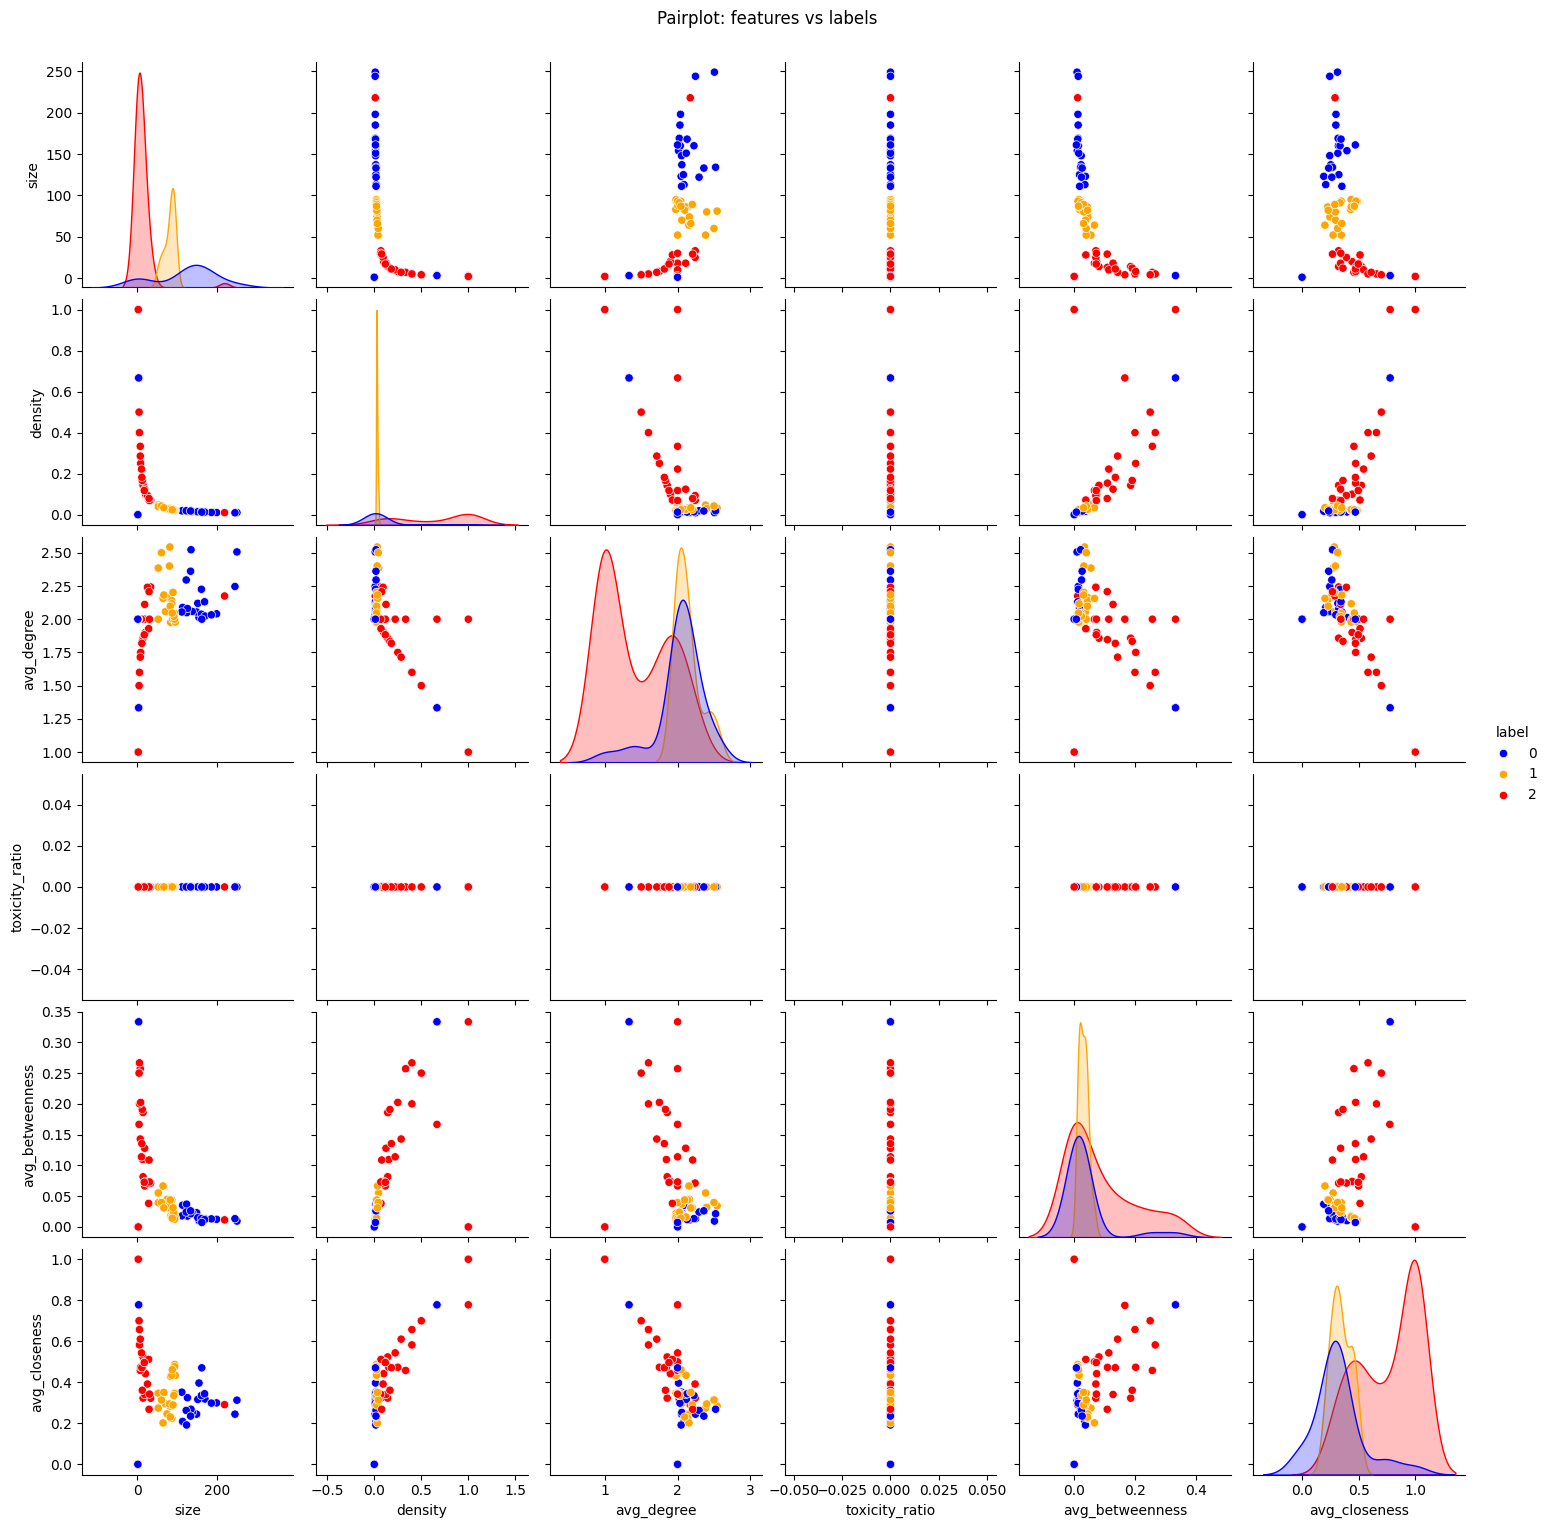

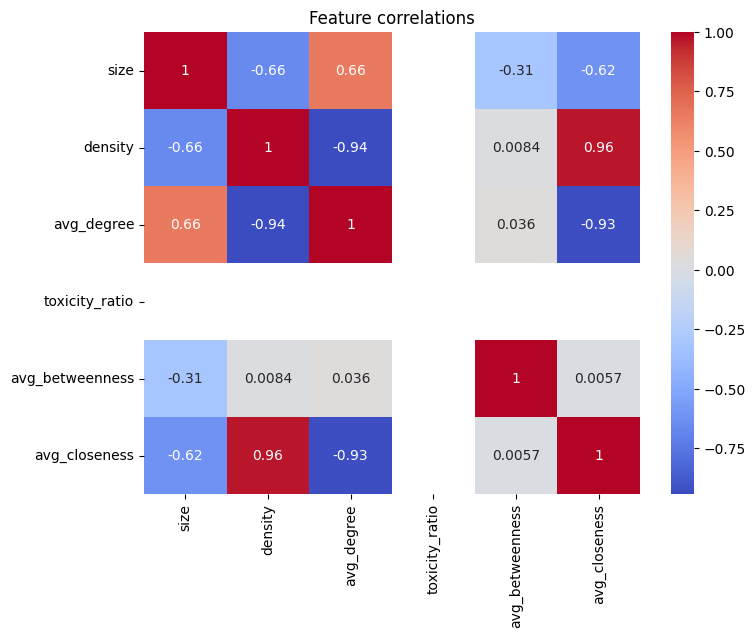

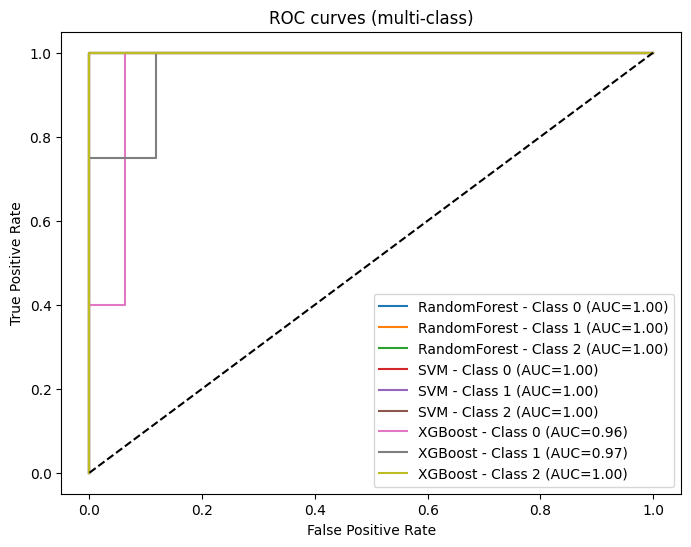

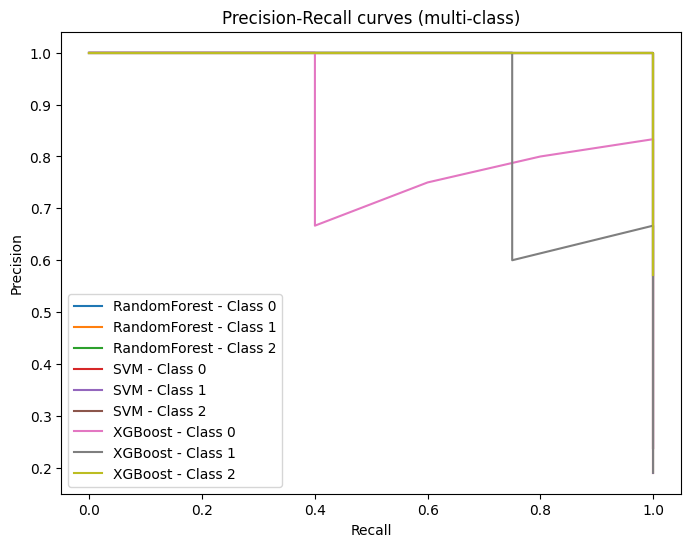

In [26]:
# =============================================
# PHASE 4 – FEATURE EXTRACTION & MULTI-CLASS LABELING
# =============================================

import pandas as pd
import numpy as np
import networkx as nx
from google.colab import drive
import os

# === Mount Google Drive
drive.mount('/content/drive', force_remount=True)
folder_path = "/content/drive/MyDrive/UM Project Nouha Imane Alexandre/sub projects/Imane/data collection"

# Load graph
gexf_path = folder_path + "/reddit_graph_final.gexf"
G = nx.read_gexf(gexf_path)
print(f"OK Graph loaded: {G.number_of_nodes()} nodes & {G.number_of_edges()} edges")

# === Extract community features
communities = {}
for node, data in G.nodes(data=True):
    comm = data.get('louvain_community')
    if comm not in communities:
        communities[comm] = []
    communities[comm].append(node)

rows = []
for comm_id, nodes in communities.items():
    subgraph = G.subgraph(nodes)
    size = len(nodes)
    density = nx.density(subgraph)
    avg_degree = sum(dict(subgraph.degree()).values()) / size if size > 0 else 0
    toxic_nodes = [n for n in nodes if G.nodes[n].get('toxic_keyword')]
    toxicity_ratio = len(toxic_nodes) / size if size > 0 else 0

    # centralities
    betweenness = nx.betweenness_centrality(subgraph) if size < 500 else {}
    closeness = nx.closeness_centrality(subgraph) if size < 500 else {}
    avg_betweenness = np.mean(list(betweenness.values())) if betweenness else 0
    avg_closeness = np.mean(list(closeness.values())) if closeness else 0

    rows.append({
        'community_id': comm_id,
        'size': size,
        'density': density,
        'avg_degree': avg_degree,
        'toxicity_ratio': toxicity_ratio,
        'avg_betweenness': avg_betweenness,
        'avg_closeness': avg_closeness
    })

df = pd.DataFrame(rows)
print("Sample of extracted features:")
print(df.head())

# === Heuristic multi-class labeling
def assign_label(row):
    if row['toxicity_ratio'] > 0.3 or row['density'] > 0.05:
        return 2   # strongly toxic
    elif row['toxicity_ratio'] > 0.15 or row['density'] > 0.02:
        return 1   # moderately toxic
    else:
        return 0   # non-toxic

df['label'] = df.apply(assign_label, axis=1)

# Add 5% noise
np.random.seed(42)
mask = np.random.rand(len(df)) < 0.05
df.loc[mask, 'label'] = np.random.choice([0,1,2], size=mask.sum())

print("Label distribution:")
print(df['label'].value_counts())

# Save features
output_features = folder_path + "/reddit_community_features_multiclass.csv"
df.to_csv(output_features, index=False)
print(f"OK Features saved ➜ {output_features}")


# =============================================
# PHASE 5 – CLASSIFICATION & EVALUATION
# =============================================

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.metrics import classification_report

X = df[['size','density','avg_degree','toxicity_ratio','avg_betweenness','avg_closeness']]
y = df['label']

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

models = {
    "RandomForest": RandomForestClassifier(random_state=42),
    "SVM": SVC(kernel='rbf', probability=True, random_state=42),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='mlogloss', random_state=42)
}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    print(f"\n=== {name} REPORT ===")
    print(classification_report(y_test, y_pred))
    scores = cross_val_score(model, X, y, cv=5, scoring='accuracy')
    print(f"OK Cross-val mean accuracy ({name}): {scores.mean():.3f} (+/- {scores.std():.3f})")


# =============================================
# PHASE 6 – VISUALIZATION
# =============================================

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc, precision_recall_curve

# Class distribution
plt.figure(figsize=(6,4))
sns.countplot(x=df['label'], hue=df['label'], palette={0:"blue",1:"orange",2:"red"}, legend=False)
plt.title("Class distribution")
plt.xlabel("Class (0=Non, 1=Moderate, 2=Strong)")
plt.ylabel("Communities")
plt.show()

# Histograms
df[['size','density','avg_degree','toxicity_ratio']].hist(figsize=(10,6), bins=20, edgecolor='black')
plt.suptitle("Feature distributions")
plt.show()

# Scatterplots
plt.figure(figsize=(7,5))
sns.scatterplot(data=df, x="size", y="density", hue="label", palette={0:"blue",1:"orange",2:"red"}, alpha=0.8)
plt.title("Size vs Density")
plt.show()

plt.figure(figsize=(7,5))
sns.scatterplot(data=df, x="avg_degree", y="toxicity_ratio", hue="label", palette={0:"blue",1:"orange",2:"red"}, alpha=0.8)
plt.title("Degree vs Toxicity ratio")
plt.show()

# Pairplot
custom_palette = {0:"blue", 1:"orange", 2:"red"}
sns.pairplot(df[['size','density','avg_degree','toxicity_ratio','avg_betweenness','avg_closeness','label']], hue="label", palette=custom_palette, diag_kind="kde")
plt.suptitle("Pairplot: features vs labels", y=1.02)
plt.show()

# Heatmap
plt.figure(figsize=(8,6))
sns.heatmap(df[['size','density','avg_degree','toxicity_ratio','avg_betweenness','avg_closeness']].corr(), annot=True, cmap="coolwarm")
plt.title("Feature correlations")
plt.show()

# ROC curves
y_bin = label_binarize(y_test, classes=[0,1,2])
plt.figure(figsize=(8,6))
for name, model in models.items():
    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X_test)
    else:
        y_score = model.decision_function(X_test)
    for i in range(y_bin.shape[1]):
        fpr, tpr, _ = roc_curve(y_bin[:, i], y_score[:, i])
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f"{name} - Class {i} (AUC={roc_auc:.2f})")
plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC curves (multi-class)")
plt.legend()
plt.show()

# Precision-Recall curves
plt.figure(figsize=(8,6))
for name, model in models.items():
    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X_test)
    else:
        y_score = model.decision_function(X_test)
    for i in range(y_bin.shape[1]):
        precision, recall, _ = precision_recall_curve(y_bin[:, i], y_score[:, i])
        plt.plot(recall, precision, label=f"{name} - Class {i}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall curves (multi-class)")
plt.legend()
plt.show()
